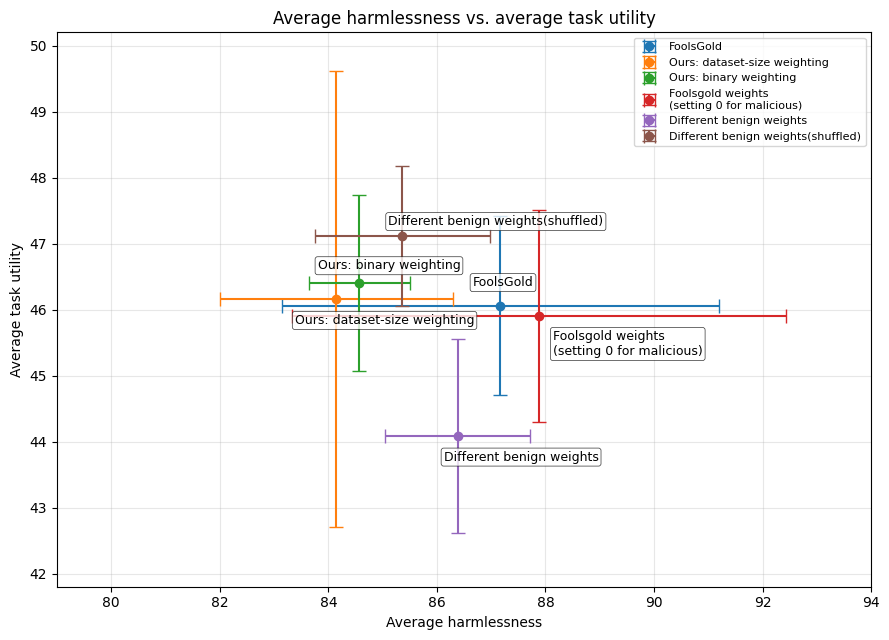

/mnt/data/average_harmlessness_vs_task_utility_selected.png


In [19]:
import matplotlib.pyplot as plt

methods = [
    "FoolsGold",
    "Ours: dataset-size weighting",
    "Ours: binary weighting",
    "Foolsgold weights\n(setting 0 for malicious)",
    "Different benign weights",
    "Different benign weights(shuffled)"
]

# Select which methods to show.
# To show all methods, use: selected_methods = methods
selected_methods = [
    "FoolsGold",
    "Ours: dataset-size weighting",
    "Ours: binary weighting",
    "Foolsgold weights\n(setting 0 for malicious)",
    "Different benign weights",
    "Different benign weights(shuffled)"
]

# Values taken from the Average rows in the photo
avg_harmless = [87.17, 84.15, 84.57, 87.88, 86.38, 85.36]
std_harmless = [4.03, 2.15, 0.93, 4.55, 1.33, 1.61]

avg_utility = [46.06, 46.16, 46.40, 45.90, 44.09, 47.11]
std_utility = [1.36, 3.46, 1.33, 1.61, 1.47, 1.06]

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown"]

plt.figure(figsize=(9, 6.5))

for method, x, y, xerr, yerr, color in zip(
    methods, avg_harmless, avg_utility, std_harmless, std_utility, colors
):
    if method not in selected_methods:
        continue

    plt.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=5,
        linestyle="None",
        color=color,
        label=method
    )

# Manually adjusted label locations to avoid overlap
label_offsets = {
    "FoolsGold": (-20, 14),
    "Ours: dataset-size weighting": (-30, -18),
    "Ours: binary weighting": (-30, 10),
    "Foolsgold weights\n(setting 0 for malicious)": (10, -28),
    "Different benign weights": (-10, -18),
    "Different benign weights(shuffled)": (-10, 8),
}

for method, x, y in zip(methods, avg_harmless, avg_utility):
    if method not in selected_methods:
        continue

    dx, dy = label_offsets[method]
    plt.annotate(
        method,
        (x, y),
        textcoords="offset points",
        xytext=(dx, dy),
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8, lw=0.5)
    )

plt.xlabel("Average harmlessness")
plt.ylabel("Average task utility")
plt.title("Average harmlessness vs. average task utility")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right", fontsize=8)

# Margins around points/error bars
plt.xlim(79, 94)
plt.ylim(41.8, 50.2)

plt.tight_layout()

# output_path = "/mnt/data/average_harmlessness_vs_task_utility_selected.png"
# plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(output_path)

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# =========================================================
# Output directory
# =========================================================
outdir = Path("safedelta_final_plots")
outdir.mkdir(exist_ok=True)

# =========================================================
# Final aggregated data
# Only Avg safety and Avg task / utility are used for plotting
# rank 2/4/6 correspond to scale 0.2/0.4/0.6
# Foolsgold and Ours/SafeDelta are single-point baselines
# =========================================================
rows = [
    # =====================================================
    # mixture 2023
    # =====================================================
    {"setting": "mixture 2023", "variant": "vanilla SafeDelta", "scale": 0.2, "avg_safety": 87.295, "avg_task": 34.51},
    {"setting": "mixture 2023", "variant": "vanilla SafeDelta", "scale": 0.4, "avg_safety": 78.58,  "avg_task": 40.92},
    {"setting": "mixture 2023", "variant": "vanilla SafeDelta", "scale": 0.6, "avg_safety": 31.295, "avg_task": 44.56},

    # {"setting": "mixture 2023", "variant": "random ranking", "scale": 0.2, "avg_safety": 86.155, "avg_task": 35.15},
    # {"setting": "mixture 2023", "variant": "random ranking", "scale": 0.4, "avg_safety": 78.075, "avg_task": 41.32},
    # {"setting": "mixture 2023", "variant": "random ranking", "scale": 0.6, "avg_safety": 38.955, "avg_task": 43.02},

    # {"setting": "mixture 2023", "variant": "clean ranking", "scale": 0.2, "avg_safety": 87.93,  "avg_task": 39.51},
    # {"setting": "mixture 2023", "variant": "clean ranking", "scale": 0.4, "avg_safety": 78.455, "avg_task": 41.19},
    # {"setting": "mixture 2023", "variant": "clean ranking", "scale": 0.6, "avg_safety": 30.785, "avg_task": 44.83},

    # {"setting": "mixture 2023", "variant": "approximate directly with dense delta", "scale": 0.2, "avg_safety": 85.4,   "avg_task": 40.375},
    # {"setting": "mixture 2023", "variant": "approximate directly with dense delta", "scale": 0.4, "avg_safety": 66.67,  "avg_task": 42.4725},
    # {"setting": "mixture 2023", "variant": "approximate directly with dense delta", "scale": 0.6, "avg_safety": 21.975, "avg_task": 45.3325},

    # {"setting": "mixture 2023", "variant": "approximate also with discordance factors", "scale": 0.2, "avg_safety": 85.775, "avg_task": 40.2825},
    # {"setting": "mixture 2023", "variant": "approximate also with discordance factors", "scale": 0.4, "avg_safety": 66.3,   "avg_task": 42.3575},
    # {"setting": "mixture 2023", "variant": "approximate also with discordance factors", "scale": 0.6, "avg_safety": 22.105, "avg_task": 45.41},

    {"setting": "mixture 2023", "variant": "Foolsgold", "avg_safety": 34.05, "avg_task": 38.45},
    {"setting": "mixture 2023", "variant": "Ours", "avg_safety": 83.25, "avg_task": 39.21},

    # =====================================================
    # no mixture
    # =====================================================
    {"setting": "no mixture", "variant": "vanilla SafeDelta", "scale": 0.2, "avg_safety": 84.77,  "avg_task": 40.95},
    {"setting": "no mixture", "variant": "vanilla SafeDelta", "scale": 0.4, "avg_safety": 51.435, "avg_task": 44.705},
    {"setting": "no mixture", "variant": "vanilla SafeDelta", "scale": 0.6, "avg_safety": 43.6,   "avg_task": 46.4575},

    # {"setting": "no mixture", "variant": "random ranking", "scale": 0.2, "avg_safety": 84.775, "avg_task": 40.51},
    # {"setting": "no mixture", "variant": "random ranking", "scale": 0.4, "avg_safety": 62.255, "avg_task": 43.7},
    # {"setting": "no mixture", "variant": "random ranking", "scale": 0.6, "avg_safety": 23.115, "avg_task": 46.37},

    # {"setting": "no mixture", "variant": "clean ranking", "scale": 0.2, "avg_safety": 84.27,  "avg_task": 42.0},
    # {"setting": "no mixture", "variant": "clean ranking", "scale": 0.4, "avg_safety": 49.545, "avg_task": 46.01},
    # {"setting": "no mixture", "variant": "clean ranking", "scale": 0.6, "avg_safety": 14.955, "avg_task": 46.27},

    # {"setting": "no mixture", "variant": "approximate directly with dense delta", "scale": 0.2, "avg_safety": 80.85, "avg_task": 43.0},
    # {"setting": "no mixture", "variant": "approximate directly with dense delta", "scale": 0.4, "avg_safety": 34.94, "avg_task": 46.2},
    # {"setting": "no mixture", "variant": "approximate directly with dense delta", "scale": 0.6, "avg_safety": 13.32, "avg_task": 47.19},

    # {"setting": "no mixture", "variant": "approximate also with discordance factors", "scale": 0.2, "avg_safety": 80.85,  "avg_task": 43.06},
    # {"setting": "no mixture", "variant": "approximate also with discordance factors", "scale": 0.4, "avg_safety": 35.065, "avg_task": 46.27},
    # {"setting": "no mixture", "variant": "approximate also with discordance factors", "scale": 0.6, "avg_safety": 13.065, "avg_task": 47.26},

    {"setting": "no mixture", "variant": "Foolsgold", "avg_safety": 83.63, "avg_task": 44.71},
    {"setting": "no mixture", "variant": "Ours", "avg_safety": 78.29, "avg_task": 42.15},

    # =====================================================
    # mixture 4096
    # corrected vanilla SafeDelta line
    # =====================================================
    {"setting": "mixture 4096", "variant": "vanilla SafeDelta", "scale": 0.2, "avg_safety": 85.395, "avg_task": 37.475},
    {"setting": "mixture 4096", "variant": "vanilla SafeDelta", "scale": 0.4, "avg_safety": 78.47,  "avg_task": 43.57},
    {"setting": "mixture 4096", "variant": "vanilla SafeDelta", "scale": 0.6, "avg_safety": 27.7,   "avg_task": 47.4225},

    # {"setting": "mixture 4096", "variant": "random ranking", "scale": 0.2, "avg_safety": 86.67,  "avg_task": 37.18},
    # {"setting": "mixture 4096", "variant": "random ranking", "scale": 0.4, "avg_safety": 78.955, "avg_task": 43.01},
    # {"setting": "mixture 4096", "variant": "random ranking", "scale": 0.6, "avg_safety": 44.605, "avg_task": 47.96},

    # {"setting": "mixture 4096", "variant": "clean ranking", "scale": 0.2, "avg_safety": 87.045, "avg_task": 37.92},
    # {"setting": "mixture 4096", "variant": "clean ranking", "scale": 0.4, "avg_safety": 77.195, "avg_task": 46.66},
    # {"setting": "mixture 4096", "variant": "clean ranking", "scale": 0.6, "avg_safety": 19.585, "avg_task": 48.17},

    # {"setting": "mixture 4096", "variant": "approximate directly with dense delta", "scale": 0.2, "avg_safety": 84.76,  "avg_task": 38.64},
    # {"setting": "mixture 4096", "variant": "approximate directly with dense delta", "scale": 0.4, "avg_safety": 65.71,  "avg_task": 48.74},
    # {"setting": "mixture 4096", "variant": "approximate directly with dense delta", "scale": 0.6, "avg_safety": 19.705, "avg_task": 48.07},

    # {"setting": "mixture 4096", "variant": "approximate also with discordance factors", "scale": 0.2, "avg_safety": 85.015, "avg_task": 38.3},
    # {"setting": "mixture 4096", "variant": "approximate also with discordance factors", "scale": 0.4, "avg_safety": 66.22,  "avg_task": 48.63},
    # {"setting": "mixture 4096", "variant": "approximate also with discordance factors", "scale": 0.6, "avg_safety": 20.72,  "avg_task": 48.18},

    {"setting": "mixture 4096", "variant": "Foolsgold", "avg_safety": 5.66, "avg_task": 46.44},
    {"setting": "mixture 4096", "variant": "Ours", "avg_safety": 74.77, "avg_task": 42.01},
]

extracted_rows = [
    # =====================================================
    # non-mixture poisoning ratio = 100%, seed = 2023
    # mapped to existing setting: no mixture
    # =====================================================
    {"setting": "no mixture", "variant": "safedelta (considering warmup)", "scale": 0.2, "avg_safety": 83.635, "avg_task": 42.59},
    {"setting": "no mixture", "variant": "safedelta (considering warmup)", "scale": 0.4, "avg_safety": 37.205, "avg_task": 46.19},
    {"setting": "no mixture", "variant": "safedelta (considering warmup)", "scale": 0.6, "avg_safety": 11.685, "avg_task": 46.08},

    {"setting": "no mixture", "variant": "safedelta clean (considering warmup)", "scale": 0.2, "avg_safety": 82.875, "avg_task": 42.59},
    {"setting": "no mixture", "variant": "safedelta clean (considering warmup)", "scale": 0.4, "avg_safety": 37.075, "avg_task": 46.66},
    {"setting": "no mixture", "variant": "safedelta clean (considering warmup)", "scale": 0.6, "avg_safety": 12.810, "avg_task": 46.15},

    {"setting": "no mixture", "variant": "random", "scale": 0.2, "avg_safety": 82.495, "avg_task": 42.65},
    {"setting": "no mixture", "variant": "random", "scale": 0.4, "avg_safety": 52.925, "avg_task": 45.45},
    {"setting": "no mixture", "variant": "random", "scale": 0.6, "avg_safety": 16.720, "avg_task": 47.08},

    # =====================================================
    # low data poisoning ratio = 50%, seed = 4096
    # mapped to existing setting: mixture 4096
    # =====================================================
    {"setting": "mixture 4096", "variant": "safedelta (considering warmup)", "scale": 0.2, "avg_safety": 85.655, "avg_task": 37.96},
    {"setting": "mixture 4096", "variant": "safedelta (considering warmup)", "scale": 0.4, "avg_safety": 76.205, "avg_task": 42.43},
    {"setting": "mixture 4096", "variant": "safedelta (considering warmup)", "scale": 0.6, "avg_safety": 24.000, "avg_task": 47.13},

    {"setting": "mixture 4096", "variant": "safedelta clean (considering warmup)", "scale": 0.2, "avg_safety": 85.150, "avg_task": 38.14},
    {"setting": "mixture 4096", "variant": "safedelta clean (considering warmup)", "scale": 0.4, "avg_safety": 75.210, "avg_task": 43.60},
    {"setting": "mixture 4096", "variant": "safedelta clean (considering warmup)", "scale": 0.6, "avg_safety": 28.890, "avg_task": 47.29},

    {"setting": "mixture 4096", "variant": "random", "scale": 0.2, "avg_safety": 86.670, "avg_task": 37.49},
    {"setting": "mixture 4096", "variant": "random", "scale": 0.4, "avg_safety": 82.775, "avg_task": 39.92},
    {"setting": "mixture 4096", "variant": "random", "scale": 0.6, "avg_safety": 50.035, "avg_task": 47.28},

    # =====================================================
    # low data poisoning ratio = 50%, seed = 2023
    # mapped to existing setting: mixture 2023
    # =====================================================
    {"setting": "mixture 2023", "variant": "safedelta (considering warmup)", "scale": 0.2, "avg_safety": 84.760, "avg_task": 40.08},
    {"setting": "mixture 2023", "variant": "safedelta (considering warmup)", "scale": 0.4, "avg_safety": 55.700, "avg_task": 44.26},
    {"setting": "mixture 2023", "variant": "safedelta (considering warmup)", "scale": 0.6, "avg_safety": 13.565, "avg_task": 46.96},

    {"setting": "mixture 2023", "variant": "safedelta clean (considering warmup)", "scale": 0.2, "avg_safety": 83.750, "avg_task": 40.34},
    {"setting": "mixture 2023", "variant": "safedelta clean (considering warmup)", "scale": 0.4, "avg_safety": 54.565, "avg_task": 43.87},
    {"setting": "mixture 2023", "variant": "safedelta clean (considering warmup)", "scale": 0.6, "avg_safety": 14.445, "avg_task": 46.71},

    {"setting": "mixture 2023", "variant": "random", "scale": 0.2, "avg_safety": 84.130, "avg_task": 40.83},
    {"setting": "mixture 2023", "variant": "random", "scale": 0.4, "avg_safety": 62.375, "avg_task": 41.57},
    {"setting": "mixture 2023", "variant": "random", "scale": 0.6, "avg_safety": 17.945, "avg_task": 46.80},
]

# rows.extend(extracted_rows)
extracted_rows.extend(rows)
df = pd.DataFrame(extracted_rows)

# Save raw plotting table
df.to_csv(outdir / "all_settings_avg_safety_avg_task.csv", index=False)

# =========================================================
# Marker configuration
# =========================================================
SPECIAL_MARKERS = {
    "Foolsgold": "^",
    "Ours": "+",
}

COLORS = {
    "Foolsgold": "tab:red",
    "Ours": "tab:brown",
}

DISPLAY_NAME = {
    "Foolsgold": "Foolsgold",
    "Ours": "Ours: Removing Malicious",
}

# Fixed x-positions for single-point methods in line plots.
# They are outside the 0.2 / 0.4 / 0.6 scale positions.
SPECIAL_XPOS = {
    "Foolsgold": 0.72,
    "Ours": 0.78,
}

# settings = ["mixture (low data + poisoning ratio 50%) 2023", "mixture (low data + poisoning ratio 50%) 4096", "non mixture (poisoning ratio 100%) 4096"]
settings = ["mixture 2023", "mixture 4096", "no mixture"]
# =========================================================
# Helper functions
# =========================================================
def safe_filename(text: str) -> str:

    return (
        text.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("–", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )


def get_curve_variants(subset: pd.DataFrame):
    """
    Return variants that have scale values and should be plotted as curves.
    """
    curve_variants = []
    for variant in subset["variant"].unique():
        s = subset[subset["variant"] == variant]
        if variant not in SPECIAL_MARKERS and s["scale"].notna().any():
            curve_variants.append(variant)
    return curve_variants


def get_special_variants(subset: pd.DataFrame):
    """
    Return single-point baseline variants.
    """
    return [v for v in subset["variant"].unique() if v in SPECIAL_MARKERS]


def scatter_special_on_axis(ax, x, y, variant, label=None):
    """
    Draw Foolsgold as triangle and Ours/SafeDelta as plus.
    This uses scatter rather than plot, so they cannot accidentally
    inherit the ordinary circle marker.
    """
    marker = SPECIAL_MARKERS[variant]
    label = label if label is not None else DISPLAY_NAME.get(variant, variant)

    if marker == "+":
        ax.scatter(
            [x],
            [y],
            marker="+",
            s=260,
            linewidths=2.8,
            label=label,
            zorder=10,
            color=COLORS.get(variant)
        )
    else:
        ax.scatter(
            [x],
            [y],
            marker=marker,
            s=150,
            label=label,
            zorder=10,
            color=COLORS.get(variant)
        )


def annotate_special_on_axis(ax, x, y, variant):
    label = DISPLAY_NAME.get(variant, variant)
    ax.annotate(
        label,
        (x, y),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8,
    )


# =========================================================
# Per-setting line plots
# =========================================================
def plot_line_metric(data: pd.DataFrame, setting: str, metric: str, ylabel: str, filename: str) -> None:
    subset = data[data["setting"] == setting].copy()

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # Scale-based curve methods
    for variant in get_curve_variants(subset):
        s = subset[
            (subset["variant"] == variant)
            & (subset["scale"].notna())
        ].sort_values("scale")

        ax.plot(
            s["scale"],
            s[metric],
            marker="o",
            label=variant,
        )

    # Single-point methods: Foolsgold triangle, SafeDelta plus
    for variant in get_special_variants(subset):
        row = subset[subset["variant"] == variant].iloc[0]
        x = SPECIAL_XPOS[variant]
        y = row[metric]

        scatter_special_on_axis(ax, x, y, variant)
        annotate_special_on_axis(ax, x, y, variant)

    ax.set_xlabel("Scale")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{setting}: {ylabel}")
    ax.set_xticks([0.2, 0.4, 0.6, 0.72, 0.78])
    ax.set_xticklabels(["0.2", "0.4", "0.6", "FG", "SD"])
    ax.set_xlim(0.18, 0.82)
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=220, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# Per-setting safety–utility tradeoff plots
# =========================================================
def plot_tradeoff(data: pd.DataFrame, setting: str, filename: str) -> None:
    subset = data[data["setting"] == setting].copy()

    fig, ax = plt.subplots(figsize=(12, 5.5))

    # Scale-based curve methods
    for variant in get_curve_variants(subset):
        s = subset[
            (subset["variant"] == variant)
            & (subset["scale"].notna())
        ].sort_values("scale")

        ax.plot(
            s["avg_safety"],
            s["avg_task"],
            marker="o",
            label=variant,
        )

        # Annotate only real scale values, never baseline rows
        for _, row in s.iterrows():
            ax.annotate(
                f"{row['scale']:.1f}",
                (row["avg_safety"], row["avg_task"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

    # Single-point methods: Foolsgold triangle, SafeDelta plus
    for variant in get_special_variants(subset):
        row = subset[subset["variant"] == variant].iloc[0]
        x = row["avg_safety"]
        y = row["avg_task"]

        scatter_special_on_axis(ax, x, y, variant)
        annotate_special_on_axis(ax, x, y, variant)

    ax.set_xlabel("Avg safety")
    ax.set_ylabel("Avg task / utility")
    ax.set_title(f"{setting}: Safety–utility tradeoff")
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(outdir / filename, dpi=220, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# Create per-setting plots
# =========================================================
for setting in settings:
    prefix = safe_filename(setting)

    plot_line_metric(
        data=df,
        setting=setting,
        metric="avg_safety",
        ylabel="Avg safety",
        filename=f"{prefix}_avg_safety.png",
    )

    plot_line_metric(
        data=df,
        setting=setting,
        metric="avg_task",
        ylabel="Avg task / utility",
        filename=f"{prefix}_avg_task.png",
    )

    plot_tradeoff(
        data=df,
        setting=setting,
        filename=f"{prefix}_safety_utility_tradeoff.png",
    )


# =========================================================
# Combined 3-panel Avg safety plot
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=False)

for ax, setting in zip(axes, settings):
    subset = df[df["setting"] == setting].copy()

    # Scale-based curve methods
    for variant in get_curve_variants(subset):
        s = subset[
            (subset["variant"] == variant)
            & (subset["scale"].notna())
        ].sort_values("scale")

        ax.plot(
            s["scale"],
            s["avg_safety"],
            marker="o",
            label=variant,
        )

    # Single-point methods
    for variant in get_special_variants(subset):
        row = subset[subset["variant"] == variant].iloc[0]
        x = SPECIAL_XPOS[variant]
        y = row["avg_safety"]

        scatter_special_on_axis(ax, x, y, variant)
        annotate_special_on_axis(ax, x, y, variant)

    ax.set_title(setting)
    ax.set_xlabel("Scale")
    ax.set_ylabel("Avg safety")
    ax.set_xticks([0.2, 0.4, 0.6, 0.72, 0.78])
    ax.set_xticklabels(["0.2", "0.4", "0.6", "FG", "SD"])
    ax.set_xlim(0.18, 0.82)

axes[-1].legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(outdir / "combined_avg_safety_all_settings.png", dpi=220, bbox_inches="tight")
plt.close(fig)


# =========================================================
# Combined 3-panel Avg task / utility plot
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 5), sharey=False)


for ax, setting in zip(axes, settings):
    subset = df[df["setting"] == setting].copy()

    # Scale-based curve methods
    for variant in get_curve_variants(subset):
        s = subset[
            (subset["variant"] == variant)
            & (subset["scale"].notna())
        ].sort_values("scale")

        ax.plot(
            s["scale"],
            s["avg_task"],
            marker="o",
            label=variant,
        )

    # Single-point methods
    for variant in get_special_variants(subset):
        row = subset[subset["variant"] == variant].iloc[0]
        x = SPECIAL_XPOS[variant]
        y = row["avg_task"]

        scatter_special_on_axis(ax, x, y, variant)
        annotate_special_on_axis(ax, x, y, variant)

    ax.set_title(setting)
    ax.set_xlabel("Scale")
    ax.set_ylabel("Avg task / utility")
    ax.set_xticks([0.2, 0.4, 0.6, 0.72, 0.78])
    ax.set_xticklabels(["0.2", "0.4", "0.6", "FG", "SD"])
    ax.set_xlim(0.18, 0.82)

axes[-1].legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(outdir / "combined_avg_task_all_settings.png", dpi=220, bbox_inches="tight")
plt.close(fig)


# =========================================================
# Combined 3-panel safety–utility tradeoff plot
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(24, 5.5), sharey=False)

for ax, setting in zip(axes, settings):
    subset = df[df["setting"] == setting].copy()

    # Scale-based curve methods
    for variant in get_curve_variants(subset):
        s = subset[
            (subset["variant"] == variant)
            & (subset["scale"].notna())
        ].sort_values("scale")

        ax.plot(
            s["avg_safety"],
            s["avg_task"],
            marker="o",
            label=variant,
        )

        for _, row in s.iterrows():
            ax.annotate(
                f"{row['scale']:.1f}",
                (row["avg_safety"], row["avg_task"]),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

    # Single-point methods
    for variant in get_special_variants(subset):
        row = subset[subset["variant"] == variant].iloc[0]
        x = row["avg_safety"]
        y = row["avg_task"]

        scatter_special_on_axis(ax, x, y, variant)
        annotate_special_on_axis(ax, x, y, variant)

    ax.set_title(setting)
    ax.set_xlabel("Avg safety")
    ax.set_ylabel("Avg task / utility")

axes[-1].legend(fontsize=8, loc="best")
fig.tight_layout()
fig.savefig(outdir / "combined_safety_utility_tradeoff_all_settings.png", dpi=220, bbox_inches="tight")
plt.close(fig)


# =========================================================
# Print output files
# =========================================================
print(f"Saved plots to: {outdir.resolve()}")
print("Files created:")
for p in sorted(outdir.glob("*")):
    print(" -", p.name)
    

Saved plots to: /home/ps9044/RPA/fedllm-attack/notebooks_final/safedelta_final_plots
Files created:
 - all_settings_avg_safety_avg_task.csv
 - combined_avg_safety_all_settings.png
 - combined_avg_task_all_settings.png
 - combined_safety_utility_tradeoff_all_settings.png
 - mixture_2023_avg_safety.png
 - mixture_2023_avg_task.png
 - mixture_2023_safety_utility_tradeoff.png
 - mixture_4096_avg_safety.png
 - mixture_4096_avg_task.png
 - mixture_4096_safety_utility_tradeoff.png
 - mixture_low_data_+_poisoning_ratio_50%_2023_avg_safety.png
 - mixture_low_data_+_poisoning_ratio_50%_2023_avg_task.png
 - mixture_low_data_+_poisoning_ratio_50%_2023_safety_utility_tradeoff.png
 - mixture_low_data_+_poisoning_ratio_50%_4096_avg_safety.png
 - mixture_low_data_+_poisoning_ratio_50%_4096_avg_task.png
 - mixture_low_data_+_poisoning_ratio_50%_4096_safety_utility_tradeoff.png
 - no_mixture_avg_safety.png
 - no_mixture_avg_task.png
 - no_mixture_safety_utility_tradeoff.png
 - non_mixture_poisoning_rati